In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%run ./utils.ipynb

/home/samuel/miniconda3/envs/tomografia-tigre/lib/python3.11/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


In [3]:
folderName = '/mnt/d/Iniciacao_cientifica/head_phantom/imagens_raw2'
flat = readRawXRMCImg(f'{folderName}/flat.dat', 1024, 1024, 'float64', 0)

flat:: Shape:(1024, 1024), Min:1.1048e+22, Max:1.1679e+22, Mean:1.1452e+22, Type:float64


Text(0.5, 1.0, 'Flat')

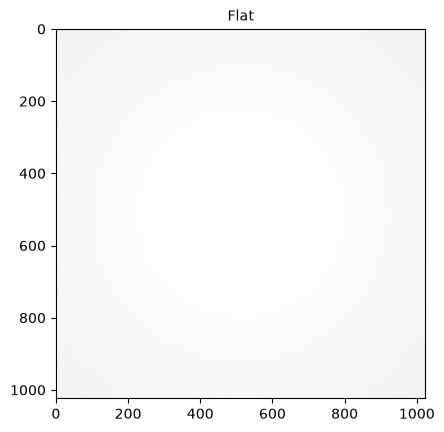

In [4]:
printImgData(flat, 'flat')
fig = plt.figure()
ax = plt.axes()
ax.imshow(flat, cmap="gray", vmin=0, vmax=flat.max())
ax.set_title('Flat', fontsize = 10)

In [5]:
#projs = readRawXRMCFolder(f'{folderName}', 'img_', 0, 359, 1, 1024, 1024, 'float64', 0)

import os
import numpy as np

def read_xrmc_float32(
    folder,
    prefix,
    inicio,
    fim,
    passo,
    nx,
    ny,
    offset=0
):
    indices = list(range(inicio, fim, passo))

    # Já cria no formato esperado pelo TIGRE:
    # (projeções, linhas, colunas)
    projs = np.empty(
        (len(indices), ny, nx),
        dtype=np.float32
    )

    for k, indice in enumerate(indices):
        arquivo = os.path.join(
            folder,
            f"{prefix}{indice:04d}.dat"
        )

        imagem = np.fromfile(
            arquivo,
            dtype=np.float64,
            count=nx * ny,
            offset=offset
        )

        if imagem.size != nx * ny:
            raise ValueError(
                f"Tamanho incorreto em {arquivo}: "
                f"{imagem.size} valores encontrados."
            )

        projs[k] = imagem.reshape(ny, nx)

        if k % 25 == 0:
            print(f"Lidas {k + 1}/{len(indices)} projeções")

    return projs



projs = read_xrmc_float32(
    folderName,
    "img_",
    0,
    719,
   1,
    1024,
    1024,
    0
)

print(projs.shape)
print(projs.dtype)

Lidas 1/719 projeções
Lidas 26/719 projeções
Lidas 51/719 projeções
Lidas 76/719 projeções
Lidas 101/719 projeções
Lidas 126/719 projeções
Lidas 151/719 projeções
Lidas 176/719 projeções
Lidas 201/719 projeções
Lidas 226/719 projeções
Lidas 251/719 projeções
Lidas 276/719 projeções
Lidas 301/719 projeções
Lidas 326/719 projeções
Lidas 351/719 projeções
Lidas 376/719 projeções
Lidas 401/719 projeções
Lidas 426/719 projeções
Lidas 451/719 projeções
Lidas 476/719 projeções
Lidas 501/719 projeções
Lidas 526/719 projeções
Lidas 551/719 projeções
Lidas 576/719 projeções
Lidas 601/719 projeções
Lidas 626/719 projeções
Lidas 651/719 projeções
Lidas 676/719 projeções
Lidas 701/719 projeções
(719, 1024, 1024)
float32


In [6]:
printImgData(projs, 'projection')

projection:: Shape:(719, 1024, 1024), Min:6.3879e+19, Max:1.1514e+22, Mean:5.1023e+21, Type:float32


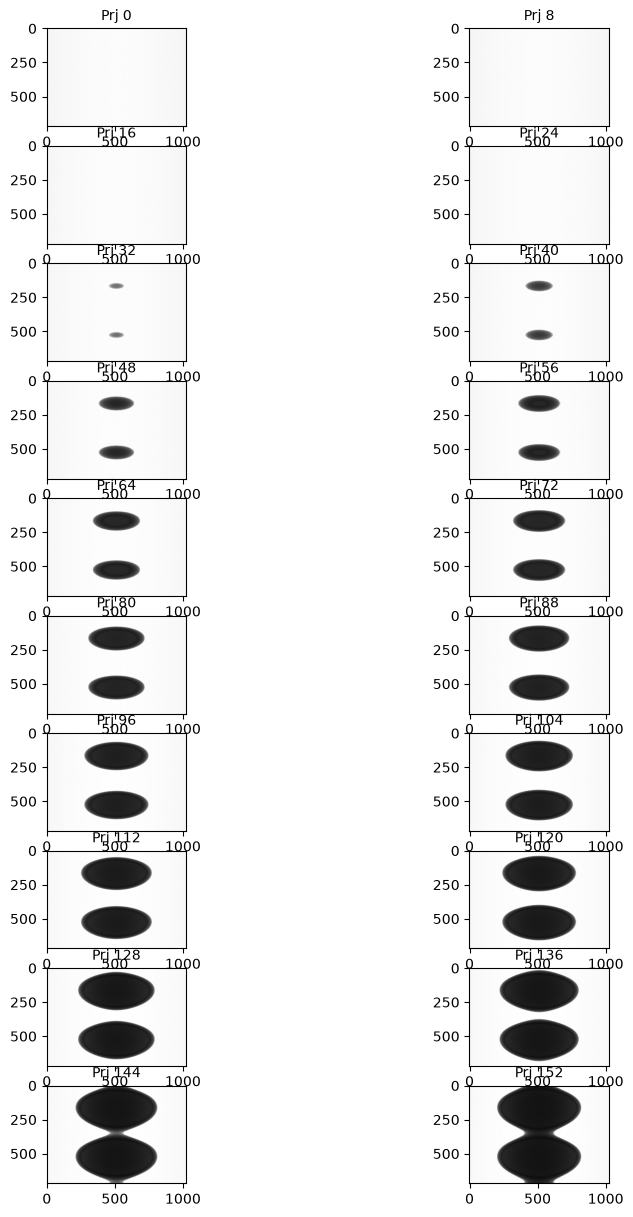

In [7]:
nroP = 20
stepP = 8
posMos = []
for i in range(nroP//2):
    posMos.append([2*i, 2*i+1])

#print(posMos)

fig, ax = plt.subplot_mosaic(posMos, figsize=((nroP//2),15))

_max = projs.max()#*0.15 

for i in range(0, nroP): 
    ax[i].imshow(projs[:,:,i*stepP], cmap="gray", vmin = 0, vmax=_max)
    ax[i].set_title(f'Prj {i*stepP}', fontsize = 10)

In [8]:
#for i in range(projs.shape[2]):
#    projs[:,:,i] = projs[:,:,i]/flat

#printImgData(projs, 'projection - flat corrected')

for i in range(projs.shape[0]):
    projs[i, :, :] = projs[i, :, :] / flat

In [9]:
outFile = f'{folderName}/sinoAula2.npz'
np.savez_compressed(outFile, sino=projs.astype('float32'))